I made modelling and nex step decisions and claude helped me quickly recode the model to run efficiently to get a new baseline

* Updated with features matching CMIP6 models
* Using fixed data

In [56]:
### Target: County-Level hourly MW

In [57]:
##!pip install shap lightgbm pandas pyarrow --quiet

In [58]:
### Cell 2 — Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import shap
from sklearn.metrics import mean_squared_error
sns.set(style="darkgrid")

In [59]:
### Cell 3 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
### Cell 4 — Load Data
def read_file(filename):
    directory = '/content/drive/My Drive/210_capstone/final_datasets/full_hist_attr/'
    return pd.read_parquet(directory + filename + '.parquet')

In [61]:
df = read_file('fixed_full_data_18to23')

In [62]:
### Cell 5 — Rename Columns
df = df.rename(columns={
    'Date':  'date',
    'County': 'county',
    'BEV':   'bev',
    'PHEV':  'phev',
    'FCEV':  'fcev',
})

In [63]:
### Cell 6 — Target Engineering (BEFORE split)
df['date'] = pd.to_datetime(df['date'])
df['elec_per_capita']     = df['electricity_usage'] / df['total_pop']
df['elec_per_capita_log'] = np.log(df['elec_per_capita'])

target = 'elec_per_capita_log'

print(df.shape)
print(df['elec_per_capita'].describe())


(127078, 72)
count    127078.000000
mean          0.019337
std           0.003428
min           0.010058
25%           0.016947
50%           0.018467
75%           0.021237
max           0.042682
Name: elec_per_capita, dtype: float64


In [64]:
ROLLING_SPECS = [
    ("cdd65_pop_roll5",       "cdd65_pop",  5,  "sum"),
    ("hdd65_pop_roll5",       "hdd65_pop",  5,  "sum"),
    ("tmax_k_pop_roll5_max",  "tmax_k_pop", 5,  "max"),
    ("tmax_k_pop_roll7_mean", "tmax_k_pop", 7,  "mean"),
]

def add_rolling_features(df):
    df = df.sort_values(["county", "date"]).copy()
    g = df.groupby("county", sort=False)
    for new_col, src_col, window, agg in ROLLING_SPECS:
        df[new_col] = g[src_col].transform(
            lambda x, w=window, a=agg: getattr(x.rolling(w, min_periods=1), a)()
        )
    return df

In [65]:
# Compute 2019 mobility baseline before dropping the columns
mobility_baseline = (
    df[df['date'].dt.year == 2019]
    .groupby(['county', 'day_of_week'])[['staying_total', 'entering_total', 'leaving_total']]
    .median()
    .reset_index()
)
print("Mobility baseline shape:", mobility_baseline.shape)


Mobility baseline shape: (406, 5)


In [66]:
df = add_rolling_features(df)

# Replace mobility with frozen 2019 baseline
df = df.drop(columns=['staying_total', 'entering_total', 'leaving_total'])
df = df.merge(mobility_baseline, on=['county', 'day_of_week'], how='left')


In [67]:
# Split
train_df = df[df['date'].dt.year <= 2021].copy()
val_df   = df[df['date'].dt.year == 2022].copy()
test_df  = df[df['date'].dt.year == 2023].copy()

print(f"Train: {train_df.shape}  ({train_df['date'].dt.year.min()}–{train_df['date'].dt.year.max()})")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")


Train: (84738, 76)  (2018–2021)
Val:   (21170, 76)
Test:  (21170, 76)


In [68]:
### Cell 8 — Features
selected_features = [
    # CATEGORICAL
    "county",
    "day_of_week",
    # CALENDAR
    "quarter",
    "month",
    "is_holiday",
    # TEMPERATURE
    "tmax_k_pop",
    "tmin_k_pop",
    "trange_k",
    # DEGREE DAYS
    "hdd65_pop",
    "cdd65_pop",
    "cdd75_pop",
    # ROLLING WEATHER
    "cdd65_pop_roll5",
    "hdd65_pop_roll5",
    "tmax_k_pop_roll5_max",
    "tmax_k_pop_roll7_mean",
    # HUMIDITY
    "spfh_peak_kgkg_pop",
    # WIND
    "wind_peak_ms_pop",
    # MOBILITY
    # "staying_total",
    # "entering_total",
    # "leaving_total",
    # DATA CENTERS
    "cuml_count",
    "cuml_sq_foot",
    "cuml_utility_cap",
    "cuml_dc_load",
    # EVs
    "bev",
    "phev",
    "fcev",
    # SOCIOECONOMIC
    "est_median_income",
    "total_pop",
]

cat_cols = ["county", "day_of_week"]
print(f"Features: {len(selected_features)}")

Features: 26


In [81]:
### Cell 9 — Train Model
def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        train_df[c] = train_df[c].astype("category")
        val_df[c]   = val_df[c].astype("category")
        val_df[c]   = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def run_model(train_df, val_df, features, params):
    X_train, y_train = train_df[features], train_df[target]
    X_val,   y_val   = val_df[features],   val_df[target]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train),
            (X_val,   y_val),],
        eval_names=["train","val"],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=300)]
    )

    preds_val = model.predict(X_val, num_iteration=model.best_iteration_)
    rmse_val  = rmse(y_val, preds_val)
    return model, rmse_val, preds_val, model.best_iteration_

params = dict(
    n_estimators=5000,
    learning_rate=0.02,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 — add this
    reg_lambda=1.0,     # L2 — add this
    random_state=42,
)

train_df, val_df = set_and_align_categories(train_df, val_df)

model, rmse_val, preds_val, best_iter = run_model(train_df, val_df, selected_features, params)

print(f"""
rmse_val (log per capita): {rmse_val:.6f}
best_iter:                 {best_iter}
""")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5442
[LightGBM] [Info] Number of data points in the train set: 84738, number of used features: 26
[LightGBM] [Info] Start training from score -3.972195
[300]	train's rmse: 0.0465009	train's l2: 0.00216233	val's rmse: 0.0730027	val's l2: 0.0053294
[600]	train's rmse: 0.0419421	train's l2: 0.00175914	val's rmse: 0.0691301	val's l2: 0.00477897
[900]	train's rmse: 0.039664	train's l2: 0.00157323	val's rmse: 0.0680445	val's l2: 0.00463006
[1200]	train's rmse: 0.0379266	train's l2: 0.00143842	val's rmse: 0.0674502	val's l2: 0.00454954
[1500]	train's rmse: 0.0365104	train's l2: 0.00133301	val's rmse: 0.0670831	val's l2: 0.00450015
[1800]	train's rmse: 0.035318	train's l2: 0.00124736	val's rmse: 0.0668836	val's l2: 0.00447341
[2100]	train's rmse: 0.0342387	train's l2: 0.00117229	val's rmse: 0.0667017	val's

In [82]:
### Cell 10 — MWh Metrics
val_df = val_df.copy()
val_df['preds_mwh'] = np.exp(preds_val) * val_df['total_pop']

def rmse_mwh(df):
    return np.sqrt(mean_squared_error(df['electricity_usage'], df['preds_mwh']))

def pct_of_mean(df):
    return 100 * rmse_mwh(df) / df['electricity_usage'].mean()

def pop_weighted_rmse_pct(df):
    w = df['total_pop'].values
    wrmse = np.sqrt(np.sum(w * (df['electricity_usage'] - df['preds_mwh'])**2) / np.sum(w))
    wmean = np.average(df['electricity_usage'], weights=w)
    return 100 * wrmse / wmean

print(f"RMSE MWh:          {rmse_mwh(val_df):,.0f}")
print(f"RMSE % of mean:    {pct_of_mean(val_df):.1f}%")
print(f"Pop-wtd RMSE %:    {pop_weighted_rmse_pct(val_df):.1f}%")


RMSE MWh:          1,561
RMSE % of mean:    11.6%
Pop-wtd RMSE %:    7.0%


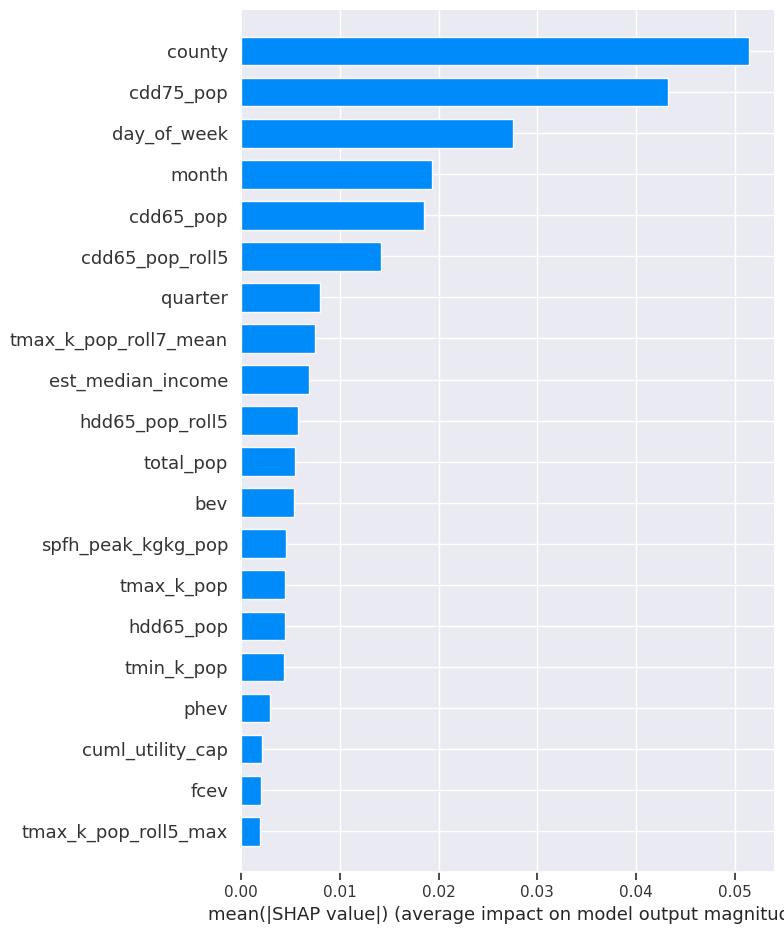

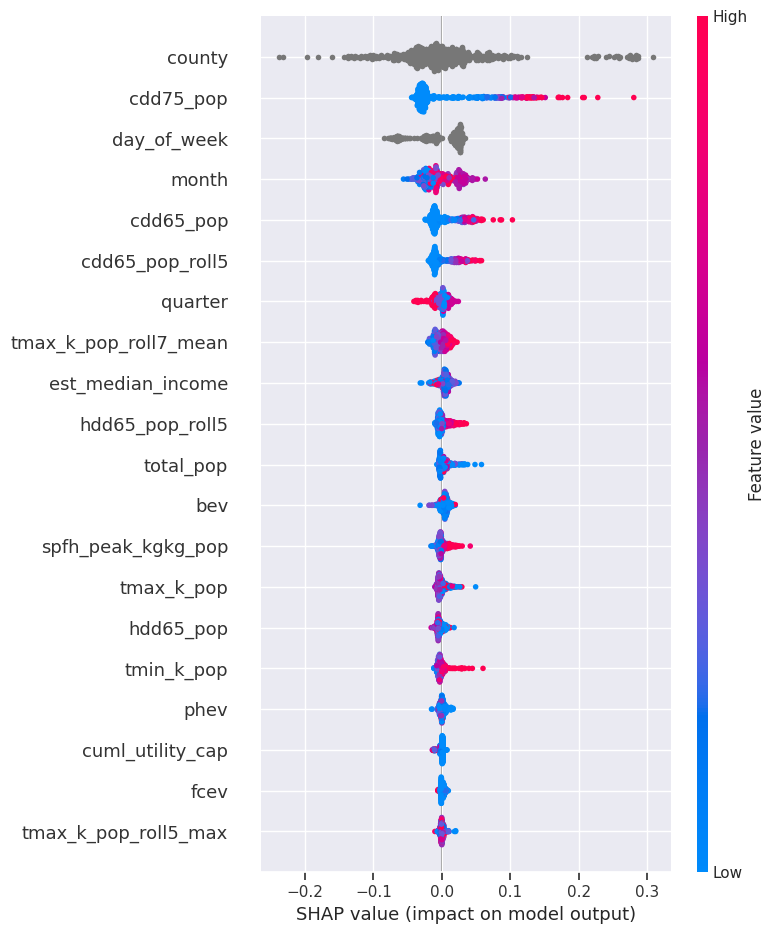

In [71]:
### Cell 11 — SHAP
explainer   = shap.TreeExplainer(model)
shap_sample = val_df[selected_features].sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type="bar")
shap.summary_plot(shap_values, shap_sample)


In [72]:
#!pip install mlflow

In [73]:
!pip install mlflow

In [74]:
import mlflow
import mlflow.lightgbm
import joblib, os, tempfile
from datetime import datetime

run_ts        = datetime.now().strftime('%Y%m%d_%H%M')
model_version = 'v3'
model_name    = f'lgbm_{target}_{model_version}_{run_ts}'

MODEL_DIR = '/content/drive/My Drive/210_capstone/models'
PRED_DIR  = '/content/drive/My Drive/210_capstone/predictions'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR,  exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{MODEL_DIR}/mlflow.db')
mlflow.set_experiment('climate-feat-lgbm')

with mlflow.start_run(run_name=f'lgbm_v3_{target}'):

    # ── Params ────────────────────────────────────────────────────────────
    mlflow.log_params(params)
    mlflow.log_param('target',       target)
    mlflow.log_param('n_features',   len(selected_features))
    mlflow.log_param('best_iter',    best_iter)
    mlflow.log_param('run_ts',       run_ts)

    # ── Log-space RMSE ────────────────────────────────────────────────────
    mlflow.log_metric('rmse_log_val', rmse_val)

    # ── MWh metrics ───────────────────────────────────────────────────────
    mlflow.log_metric('rmse_mwh_val',        rmse_mwh(val_df))
    mlflow.log_metric('rmse_pct_mean_val',   pct_of_mean(val_df))
    mlflow.log_metric('pop_wtd_rmse_pct_val',pop_weighted_rmse_pct(val_df))

    # ── Log model ─────────────────────────────────────────────────────────
    mlflow.lightgbm.log_model(model, artifact_path='lgbm')

    # ── Feature list as artifact ──────────────────────────────────────────
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
        f.write('\n'.join(selected_features))
        tmp = f.name
    mlflow.log_artifact(tmp, artifact_path='metadata')
    os.unlink(tmp)

    print(f'MLflow run logged — climate-feat-lgbm / {model_name}')
    print(f'  rmse_mwh_val:         {rmse_mwh(val_df):,.0f} MWh')
    print(f'  pop_wtd_rmse_pct_val: {pop_weighted_rmse_pct(val_df):.1f}%')

# ── Export ────────────────────────────────────────────────────────────────────
joblib.dump(model,             f'{MODEL_DIR}/{model_name}.pkl')
joblib.dump(selected_features, f'{MODEL_DIR}/{model_name}_features.pkl')
mobility_baseline.to_parquet(  f'{MODEL_DIR}/mobility_baseline_2019.parquet')

val_df['elec_per_capita_log_actual'] = val_df[target]
val_df['elec_per_capita_log_pred']   = preds_val

pred_cols = ['county', 'date', 'total_pop', 'electricity_usage',
             'elec_per_capita_log_actual', 'elec_per_capita_log_pred', 'preds_mwh']
val_df[pred_cols].to_parquet(f'{PRED_DIR}/{model_name}_preds_val.parquet', index=False)

print(f'\nExported:')
print(f'  {model_name}.pkl')
print(f'  {model_name}_features.pkl')
print(f'  mobility_baseline_2019.parquet')
print(f'  {model_name}_preds_val.parquet')

2026/02/24 17:31:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 17:31:55 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — climate-feat-lgbm / lgbm_elec_per_capita_log_v3_20260224_1731
  rmse_mwh_val:         1,580 MWh
  pop_wtd_rmse_pct_val: 7.1%

Exported:
  lgbm_elec_per_capita_log_v3_20260224_1731.pkl
  lgbm_elec_per_capita_log_v3_20260224_1731_features.pkl
  mobility_baseline_2019.parquet
  lgbm_elec_per_capita_log_v3_20260224_1731_preds_val.parquet
